# Benchmark 1D 

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras


from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

Ray module not found. Multiprocessing features are not available


True

In [2]:
seed = 11
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

# Creation of the model

In [3]:
#Benchmark1
lowfid = lambda x: np.sin(8*np.pi*x/5)
highfid = lambda x: (x/5-np.sqrt(2))*lowfid(x)**2
Nhf = 15
Nlf = 64
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 3000
NepoHF = 3000

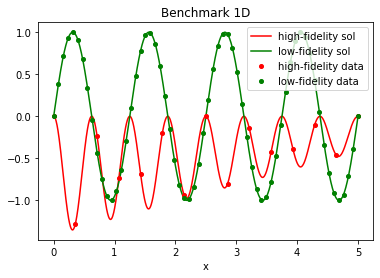

In [4]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

The function training took 34.4899959564209 seconds.


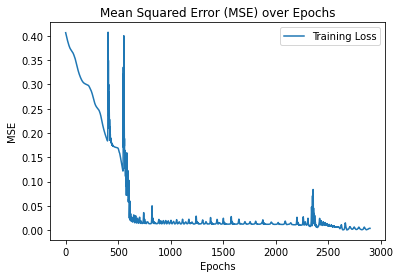

Test MSE: 0.8990941223454936
R^2: -5.639024313817868


In [5]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
(mse_LF,R_LF)=modelLF.performance(x_test,highfid(x_test))

## High fidelity model

The function training took 33.35134673118591 seconds.


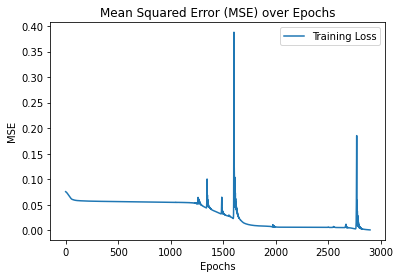

Test MSE: 0.1706513256160487
R^2: -0.2601108958365952


In [6]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R_HF)=modelHF.performance(x_test,highfid(x_test))

## 2 Step model

The function training took 33.53348445892334 seconds.


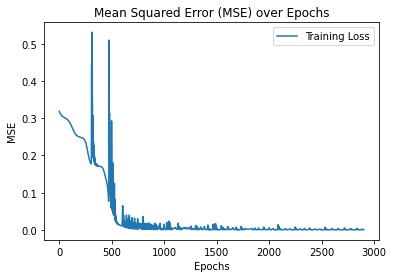

The function training took 29.88006567955017 seconds.


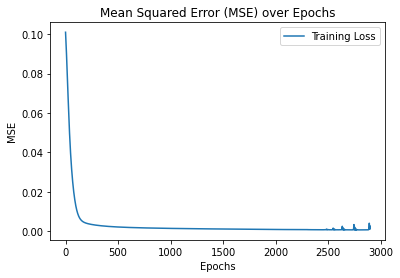

Test MSE: 0.0005760179310175296
R^2: 0.9957466110008103


In [7]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

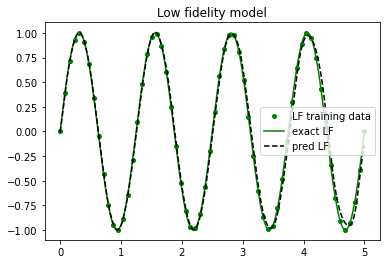

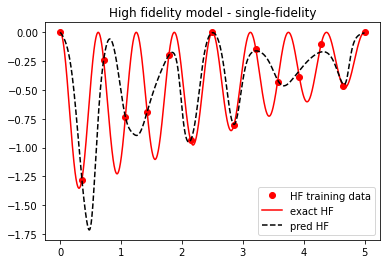

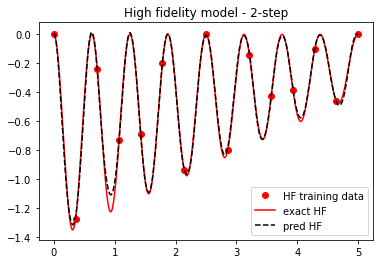

In [8]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

# MCMC using tinyDA

In [9]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.5,1.5,2.5,3.5])
mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.5  # like Manzoni paper -> 1% of the width of the ranges 
sigma=0.6
rwmh_cov = np.eye(len(real_x))*3 # !
rmwh_scaling = 0.1
rwmh_adaptive = False
#iterations =20000
#burnin = 5000
iterations=3000#8000
burnin=1000#4000
n_chains=2

# MF

real values are [0.5 1.5 2.5 3.5]
Sampling chain 1/2


Running chain, α = 0.62: 100%|██████████| 3000/3000 [09:24<00:00,  5.31it/s]  


Sampling chain 2/2


Running chain, α = 0.62: 100%|██████████| 3000/3000 [07:44<00:00,  6.46it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.471 2.58  2.062 2.569]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.471  1.306  -0.937    4.054      0.631    0.512       5.0      24.0   
x1  2.580  1.268   0.250    4.766      0.517    0.385       6.0      52.0   
x2  2.062  2.081  -1.678    5.414      1.201    0.949       3.0      41.0   
x3  2.569  1.287   0.201    4.792      0.327    0.235      16.0      63.0   

    r_hat  
x0   1.40  
x1   1.25  
x2   1.71  
x3   1.12  
Autocorrelation...
the difference between estimated values [0.971 1.08  0.438 0.931]
 the difference between outputs of two models are [0.41492748 0.88390216 0.66458201 0.54895845]


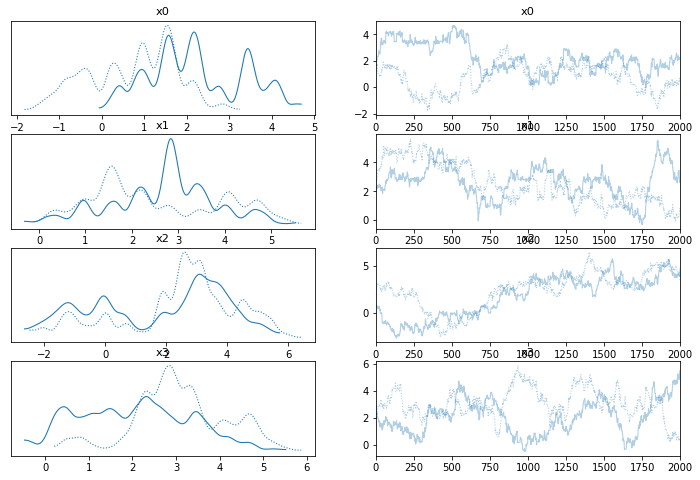

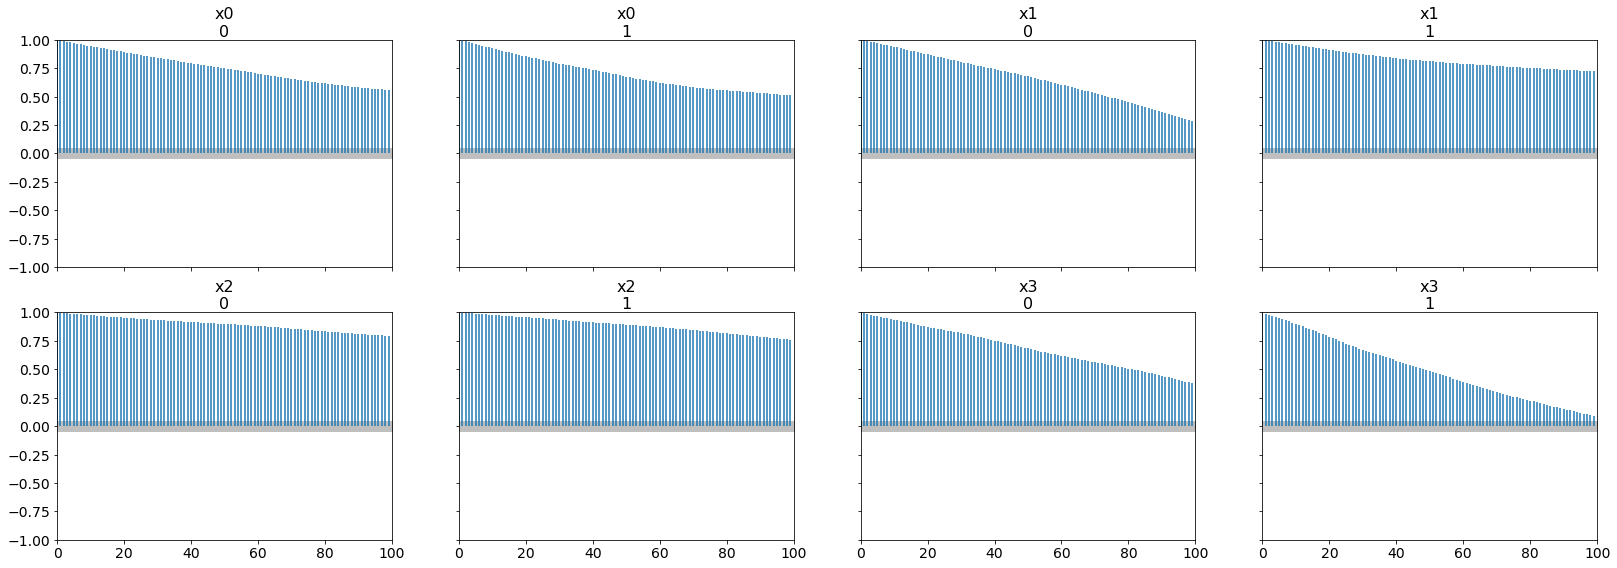

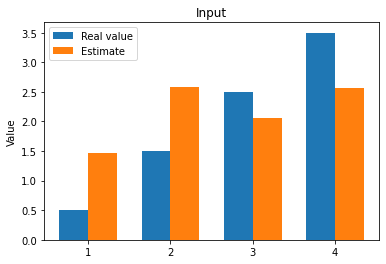

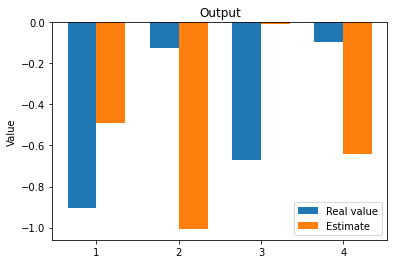

The function inverse took 1090.0222253799438 seconds.


In [19]:

estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [0.5 1.5 2.5 3.5]
Sampling chain 1/2


Running chain, α = 0.17: 100%|██████████| 3000/3000 [08:21<00:00,  5.98it/s]


Sampling chain 2/2


Running chain, α = 0.12: 100%|██████████| 3000/3000 [09:08<00:00,  5.47it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.657 1.788 1.972 2.531]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.657  1.626  -0.163    5.637      0.145    0.103     125.0     312.0   
x1  1.788  1.366  -0.590    4.152      0.100    0.072     191.0     284.0   
x2  1.972  1.410  -0.532    4.641      0.101    0.071     198.0     306.0   
x3  2.531  1.646  -0.315    5.714      0.200    0.142      68.0     232.0   

    r_hat  
x0   1.00  
x1   1.02  
x2   1.01  
x3   1.04  
Autocorrelation...
the difference between estimated values [2.157 0.288 0.528 0.969]
 the difference between outputs of two models are [0.06437531 0.8314558  0.22248833 0.62147695]


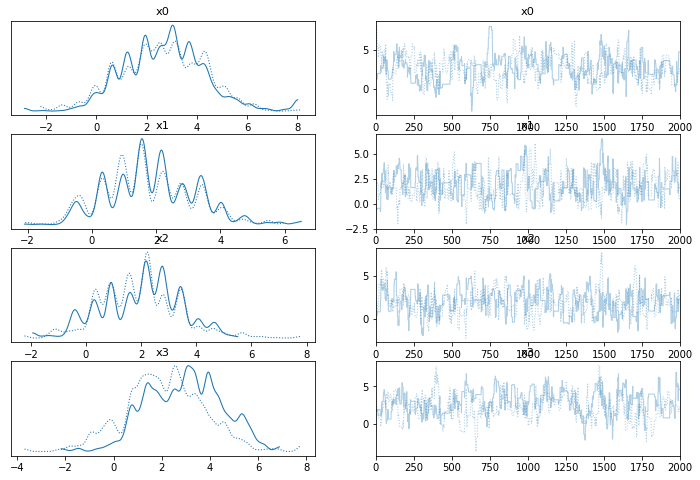

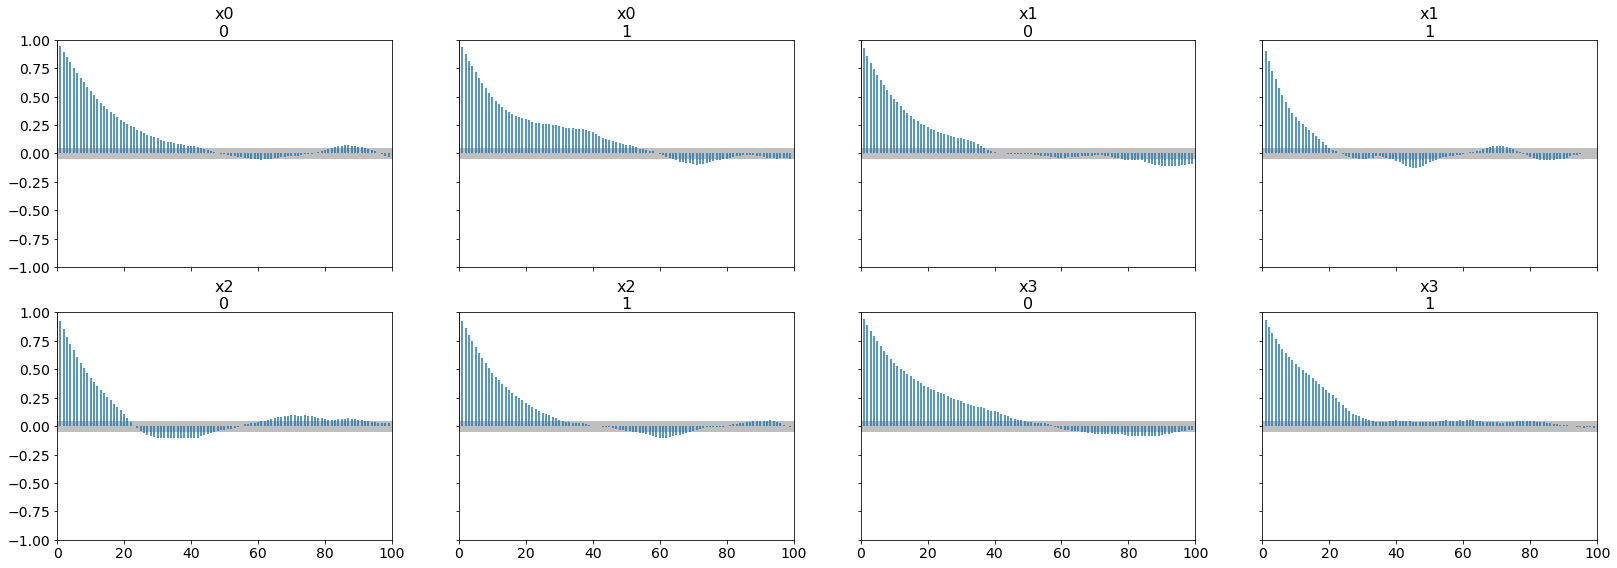

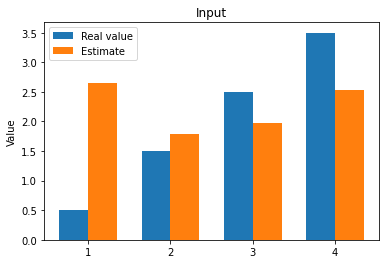

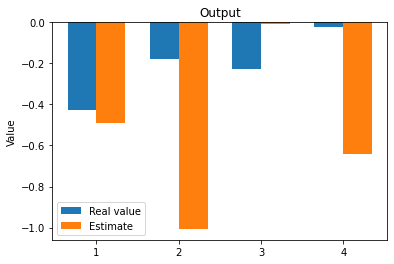

The function inverse took 1106.027232170105 seconds.


In [20]:
rwmh_adaptive = True
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [0.5 1.5 2.5 3.5]
Sampling chain 1/2


Running chain, α = 0.27: 100%|██████████| 3000/3000 [19:11<00:00,  2.61it/s]


Sampling chain 2/2


Running chain, α = 0.19: 100%|██████████| 3000/3000 [16:16<00:00,  3.07it/s] 
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


estimated values are [2.22  2.699 2.49  2.407]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.220  1.559  -0.639    4.959      0.099    0.070     251.0     464.0   
x1  2.699  1.551  -0.735    5.298      0.097    0.068     258.0     367.0   
x2  2.490  1.554  -0.674    5.179      0.094    0.067     274.0     347.0   
x3  2.407  1.534  -0.591    5.195      0.106    0.075     213.0     257.0   

    r_hat  
x0   1.03  
x1   1.00  
x2   1.01  
x3   1.01  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...
the difference between estimated values [1.72  1.199 0.01  1.093]
 the difference between outputs of two models are [0.45258778 0.40696937 0.00324985 0.45447341]


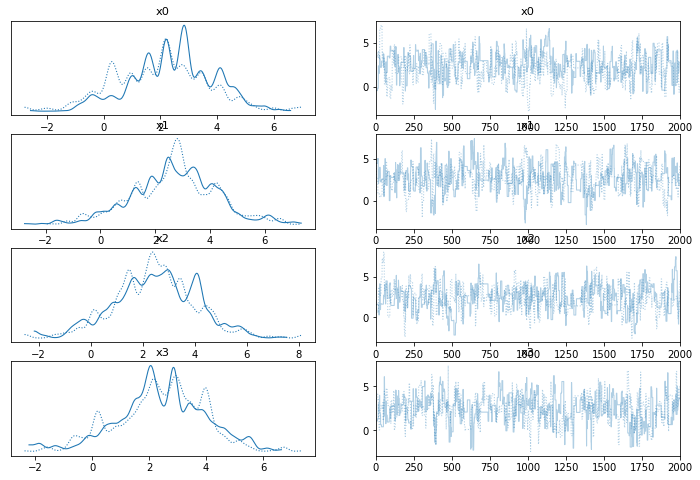

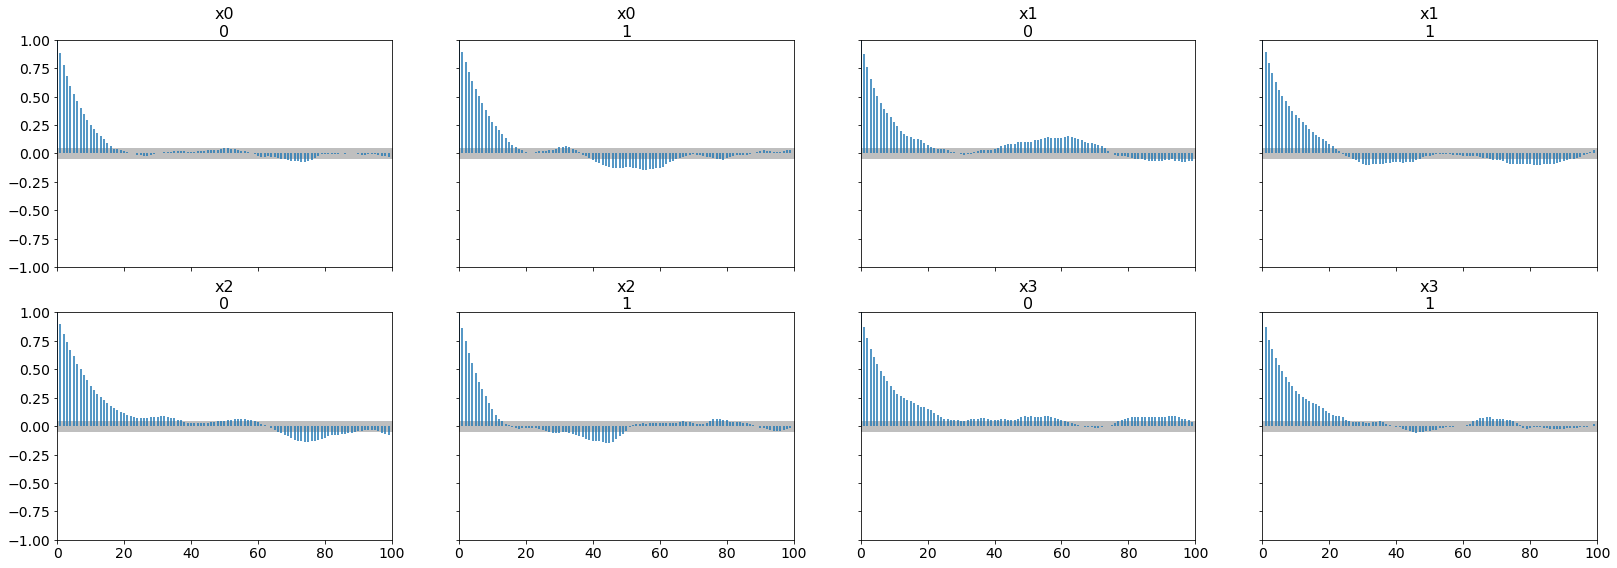

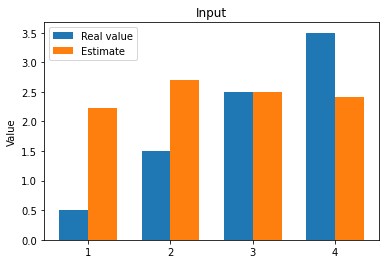

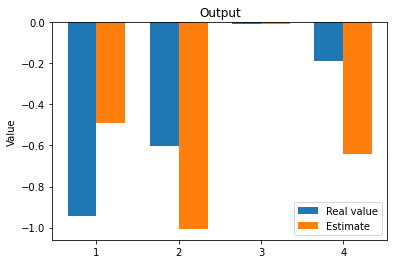

The function inverse took 2262.3574619293213 seconds.


In [11]:
rwmh_adaptive = True
estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma**2*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive,algo="AM")

### Low Fidelity

real values are [0.5 1.5 2.5 3.5]
Sampling chain 1/2


Running chain, α = 0.68: 100%|██████████| 3000/3000 [04:09<00:00, 12.03it/s]


Sampling chain 2/2


Running chain, α = 0.68: 100%|██████████| 3000/3000 [03:53<00:00, 12.87it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.356 3.823 2.886 1.603]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.356  1.016  -0.340    3.604      0.347    0.300      10.0      31.0   
x1  3.823  1.249   1.866    5.776      0.829    0.684       3.0      25.0   
x2  2.886  1.079   1.183    5.248      0.273    0.212      17.0      31.0   
x3  1.603  2.129  -2.726    5.181      1.159    0.903       3.0      14.0   

    r_hat  
x0   1.24  
x1   2.06  
x2   1.11  
x3   1.61  
Autocorrelation...
the difference between estimated values [0.856 2.323 0.386 1.897]
 the difference between outputs of two models are [0.12219098 0.71676946 1.0030972  1.951877  ]


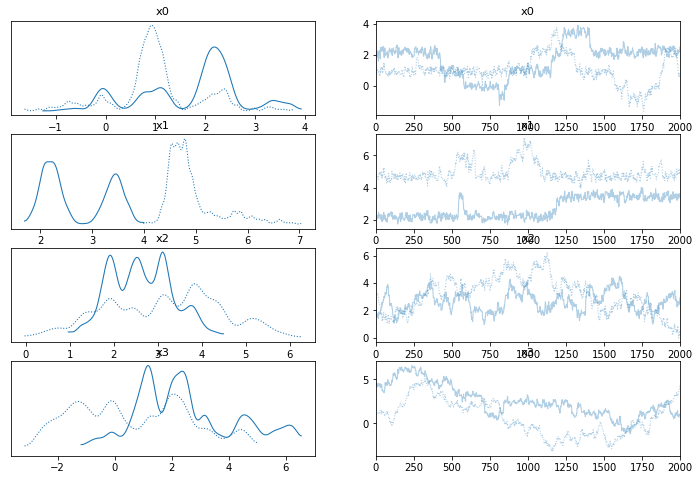

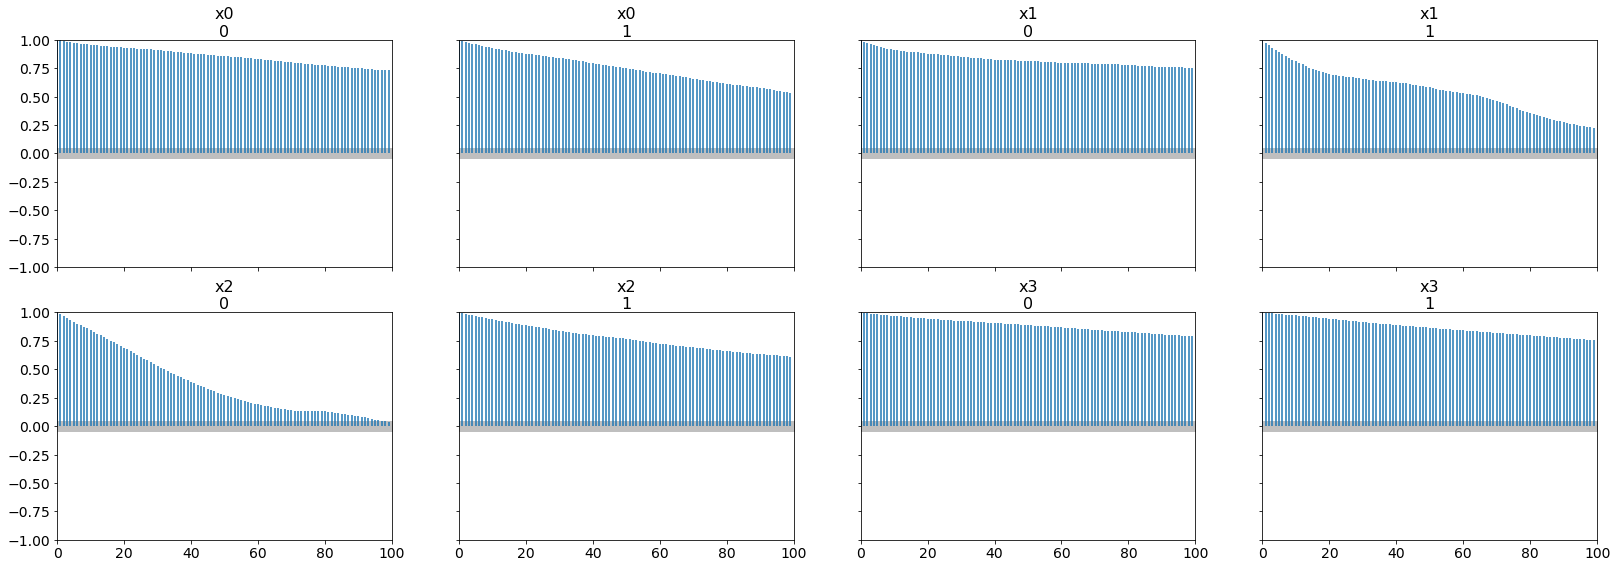

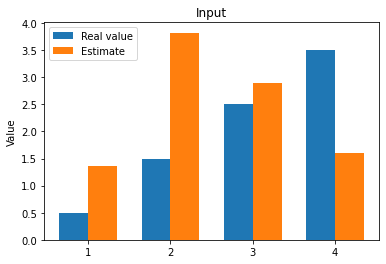

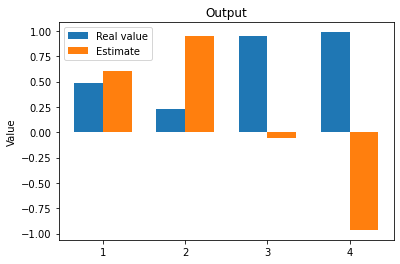

The function inverse took 507.73793148994446 seconds.


In [21]:
rwmh_adaptive = False
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

## High fidelity


In [22]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

real values are [0.5 1.5 2.5 3.5]
